In [ ]:
# 書籍版では"!"がないですが、Jupyter Notebook環境の場合は必要となります
# すでにインストールされていれば不要
!pip install numpy matplotlib pylatexenc quri-parts quri_parts.qulacs quri_parts.qiskit

In [2]:
import numpy as np
from sympy import nsimplify
import matplotlib.pyplot as plt
from fractions import Fraction

from quri_parts.circuit import LinearMappedUnboundParametricQuantumCircuit
from quri_parts.core.operator import Operator, pauli_label
from quri_parts.core.state import quantum_state
from quri_parts.qulacs.estimator import create_qulacs_vector_estimator
from quri_parts.qiskit.circuit import convert_circuit

In [3]:
obs1 = Operator(
    {
    pauli_label("Z0 Z1"): 1/np.sqrt(2),
    pauli_label("Z0 X1"): 1/np.sqrt(2),
    }
)

obs2 = Operator(
    {
    pauli_label("Z0 Z1"): 1/np.sqrt(2),
    pauli_label("Z0 X1"): -1/np.sqrt(2),
    }
)

obs3 = Operator(
    {
    pauli_label("X0 Z1"): 1/np.sqrt(2),
    pauli_label("X0 X1"): 1/np.sqrt(2),
    }
)


obs4 = Operator(
    {
    pauli_label("X0 Z1"): 1/np.sqrt(2),
    pauli_label("X0 X1"): -1/np.sqrt(2),
    }
)

print(f"観測量 AB: {obs1}")
print(f"観測量 AB': {obs2}")
print(f"観測量 A'B: {obs3}")
print(f"観測量 A'B': {obs4}")

観測量 AB: 0.7071067811865475*Z0 Z1 + 0.7071067811865475*Z0 X1
観測量 AB': 0.7071067811865475*Z0 Z1 + -0.7071067811865475*Z0 X1
観測量 A'B: 0.7071067811865475*X0 Z1 + 0.7071067811865475*X0 X1
観測量 A'B': 0.7071067811865475*X0 Z1 + -0.7071067811865475*X0 X1


In [4]:
def CHSH_circuit(circuit):
    circuit.add_H_gate(0)
    circuit.add_CNOT_gate(0, 1)
    circuit.add_X_gate(0)
    circuit.add_Z_gate(1)
    theta = circuit.add_parameter("theta")
    circuit.add_ParametricRY_gate(1, {theta: 1.0})
    return circuit

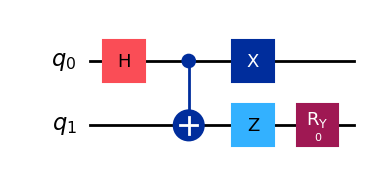

In [5]:
circuit = LinearMappedUnboundParametricQuantumCircuit(2)
CHSH_circuit(circuit)
bound_circuit = circuit.bind_parameters([0.0])
qiskit_circuit = convert_circuit(bound_circuit)
qiskit_circuit.draw("mpl", fold=-1)

In [6]:
estimator = create_qulacs_vector_estimator()
state = quantum_state(2, circuit=bound_circuit)
exp1 = estimator(obs1, state).value.real
exp2 = estimator(obs2, state).value.real
exp3 = estimator(obs3, state).value.real
exp4 = estimator(obs4, state).value.real
expectation_value = exp1 + exp2 + exp3 - exp4
print(f"期待値: {expectation_value} = {nsimplify(expectation_value)}")

期待値: -2.8284271247461894 = -2*sqrt(2)


In [7]:
estimator = create_qulacs_vector_estimator()

# アリスとボブの測定方向の間の角度を変化させるためのパラメータ
angles = list(np.linspace(0, 2 * np.pi, 51))

# 異なる角度における期待値を計算してリストに格納する
expectation_value_list = []
for i in range(0, 51):
    circuit = LinearMappedUnboundParametricQuantumCircuit(2)
    CHSH_circuit(circuit)
    bound_circuit = circuit.bind_parameters([angles[i]])
    state = quantum_state(2, circuit=bound_circuit)
    exp1 = estimator(obs1, state).value.real
    exp2 = estimator(obs2, state).value.real
    exp3 = estimator(obs3, state).value.real
    exp4 = estimator(obs4, state).value.real
    expectation_value = exp1 + exp2 + exp3 - exp4
    expectation_value_list.append(expectation_value)

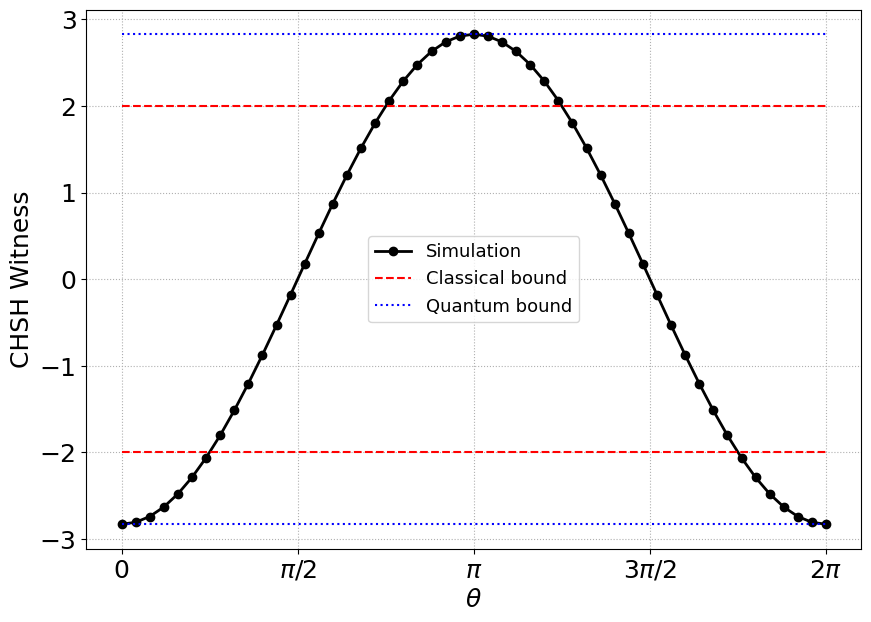

In [8]:
def make_pi_ticks(step=np.pi/8, display_step=4):
    """π単位の目盛りとラベルを作成する"""
    theta = 2*np.pi
    tick_positions = np.arange(0, theta + step/2, step)
    tick_labels = []

    for i, pos in enumerate(tick_positions):
        if i % display_step != 0:
            continue

        frac = Fraction(i, 8)
        if i == 0:
            tick_labels.append('0')
        elif frac.denominator == 1:
            if frac.numerator == 1:
                tick_labels.append('$\\pi$')
            else:
                tick_labels.append(f'{frac.numerator}$\\pi$')
        else:
            if frac.numerator == 1:
                label = f'$\\pi$/{frac.denominator}'
                tick_labels.append(label)
            else:
                label = f'{frac.numerator}$\\pi$/{frac.denominator}'
                tick_labels.append(label)

    # positions も同じ間引きに合わせる
    tick_positions = tick_positions[::display_step]
    return tick_positions, tick_labels

plt.figure(figsize=(10, 7))

# メインデータ
plt.plot(
angles, expectation_value_list, marker="o", linestyle="solid", color="black", linewidth=2, label='Simulation'
)

# 境界線 (CHSH)
bounds = [
(2, 'red', 'Classical bound'),
(-2, 'red', None),
(2*np.sqrt(2), 'blue', 'Quantum bound'), (-2*np.sqrt(2), 'blue', None),
]

for value, color, label in bounds:
    plt.plot(
    angles, [value]*len(angles),
    ls='--' if abs(value) == 2 else ':', color=color, label=label
    )

# x 軸 πラベル
xticks, xticklabels = make_pi_ticks()
plt.xticks(xticks, xticklabels, fontsize=18)
plt.xlabel("$\\theta$", fontsize=18)
plt.ylabel("CHSH Witness", fontsize=18)
plt.yticks(fontsize=18)
plt.grid(linestyle='dotted')
plt.legend(fontsize=13)
plt.show()